La temperatura media annuale è: 14.991689362452579
La deviazione standard della temperatura media è: 14.623812831552073
La minima annuale è stata: -9.822871266168567
La massima annuale è stata: 39.93828191986079
La temperatura giornaliera ha superato la media annuale 183 volte
La prima volta che la temperatura ha superato i 38 gradi è avvenuto il giorno 49


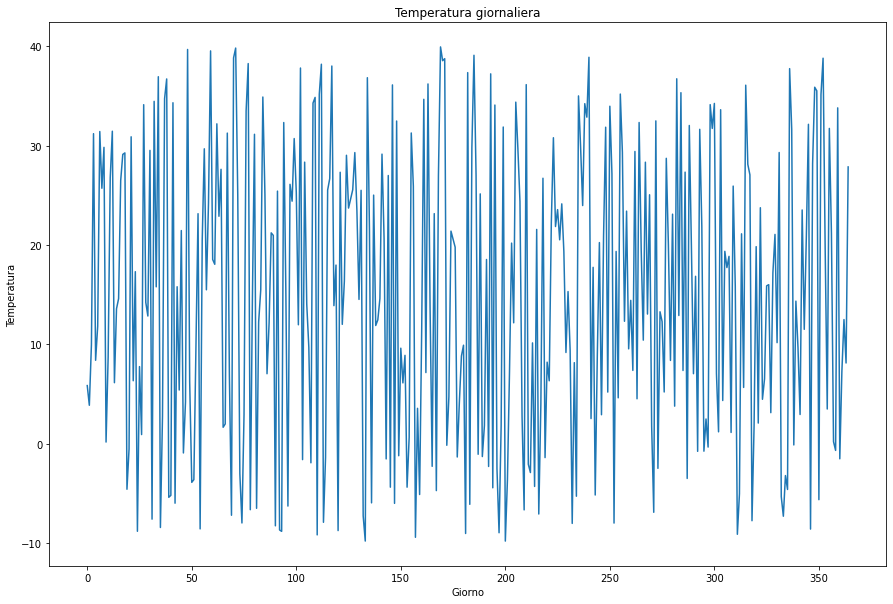

In [79]:
# 1 Uso Numpy per analizzare le temperature di un anno ed estrarre alcune informazioni di base
# 1.1 Genero io la distribuzione delle temperature usando il pacchetto random

import numpy as np
import random
import matplotlib.pyplot as plt


n_giorni = 365 # numero di giorni
T_max = 40 # Temperatura minima 
T_min = -10 # Temperatura massima
temperature = np.random.uniform(T_min, T_max, size = n_giorni) # Temperature annue generate con una distribuzione uniforme

# Valutazione delle temperatura media, deviazione standard, minima e massima
media = np.mean(temperature) # Temperatura media annuale
deviazione_standard = np.std(temperature) # Deviazione standard
minima = np.min(temperature) # Temperatura minima
massima = np.max(temperature) # Temperatura massima

# Stampo a schermo le informazioni relative alla media, std, minima e massima
print("La temperatura media annuale è:", media)
print("La deviazione standard della temperatura media è:", deviazione_standard)
print("La minima annuale è stata:", minima)
print("La massima annuale è stata:", massima)

# Valuto quanti giorni sono stati piu' caldi della media 
giorni_caldi = np.where(temperature >= media, 1 ,0).sum()
print("La temperatura giornaliera ha superato la media annuale", giorni_caldi, "volte")
# Valuto qual'è stato il primo giorno in cui la temperatura ha superato i 38 gradi
print("La prima volta che la temperatura ha superato i 38 gradi è avvenuto il giorno", (temperature > 38).argmax()+1)


# Conversione da gradi Celsius a Fahrenheit
temperature_F = temperature*1.8 +32



# Grafico delle temperature VS giorno dell'anno
plt.figure(figsize=(15,10))
plt.plot(temperature[:])
plt.xlabel("Giorno")
plt.ylabel("Temperatura")
plt.title("Temperatura giornaliera")
plt.show()






Il numero di dati mancanti è: 0


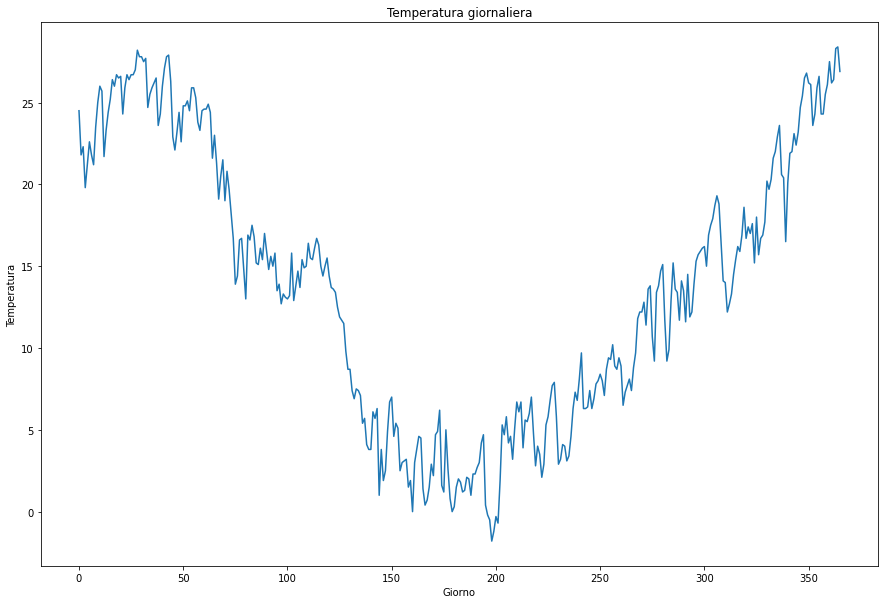

La temperatura media annuale è stati di: 13.72513661202186 gradi Celsius
La temperatura minima è stata di: -1.8 gradi Celsius
La temperatura massima è stata di: 28.4 gradi Celsius
Il numero di giorni con una temperatura superiore alla media è stato di: 187
Il primo giorno in cui la temperatura è scesa sotto lo zero è stato il: 197


In [2]:
# 2 Uso le temperature presente alla pagina web di https://www.arpa.piemonte.it/rischi_naturali/snippets_arpa_graphs/dati_giornalieri_meteo/?statid=PIE-001292-900-1997-12-23&param=T

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random


df = pd.read_csv("VENARIA CERONDA_t.csv") #Importo il file csv come data frame

df_temperature = df.iloc[:,1] # Seleziono la colonna delle temperature medie

# Controllo se ci sono dati mancanti
print("Il numero di dati mancanti è:", df_temperature.isna().sum())

# Converto la colonna delle temperature in un array di Numpy
temperature = df_temperature.to_numpy()

# Creo il grafico annuale delle temperatura giornaliera
plt.figure(figsize=(15,10))
plt.plot(temperature[:])
plt.xlabel("Giorno")
plt.ylabel("Temperatura")
plt.title("Temperatura giornaliera")
plt.show()

# Operazioni di statistica di base
media = np.mean(temperature) # media
deviazione_media = np.std(temperature) #std
minima = np.min(temperature) # T minima 
massima = np.max(temperature) # T massima

# Stampo a schermo i risultati
print("La temperatura media annuale è stati di:", media, "gradi Celsius")
print("La temperatura minima è stata di:", minima, "gradi Celsius")
print("La temperatura massima è stata di:", massima, "gradi Celsius")

print("Il numero di giorni con una temperatura superiore alla media è stato di:", np.where(temperature > media, 1, 0).sum())
print("Il primo giorno in cui la temperatura è scesa sotto lo zero è stato il:", (temperature <0).argmax() +1)




In [3]:
df.head()

,DATA,Temperatura media (°C),Temperatura massima (°C),Temperatura minima (°C),Temperatura classe,Gradi Giorno riscaldamento base 20 (°C),Gradi Giorno riscaldamento base 18 (°C),Gradi Giorno raffrescamento base 21 (°C)
0,2024-06-30,24.5,30.1,18.8,MZ00,0.0,0.0,3.5
1,2024-07-01,21.8,29.8,16.1,MZ00,0.0,0.0,0.0
2,2024-07-02,22.3,29.8,14.4,MZ00,0.0,0.0,0.0
3,2024-07-03,19.8,24.4,15.5,MZ00,0.1,0.0,0.0
4,2024-07-04,21.2,28.1,13.5,MZ00,0.0,0.0,0.0


In [303]:
# 3 Uso le stesse temperature precedenti. Questa volta mi propongo di individuare
# 3.1 statistiche mensili (media, min, max)
# 3.2 anomalie (giorni molto caldi o freddi)

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

df = pd.read_csv("VENARIA CERONDA_t.csv") # Carico il set di dati

df.set_index(df.columns[0], inplace = True) # Imposto la data come indice 

df = df.iloc[:,[0,1,2]] # Estraggo il data frame con le temperature media, massima e minima

df.columns = ["Temperatura Media", "Temperatura Massima", "Temperatura Minima"] # Per semplicità cambio i nomi delle colonne d'interesse

# Controllo se sono presenti dati mancanti in tutto il DataFrame
if df.isna().any().any() == True:
    print("Attenzione ci sono dei dati mancanti")

df.index = pd.to_datetime(df.index, format="%Y-%m-%d") # converto l'indice a "datetime"
df = df.sort_index() # ordino il DataFrame dal primo giorno presente

df.head()

df = df.drop(index="2024-06-30") # Cancello la prima riga per avere le temperature di un anno dal 01/07/2024 al 30/06/2025

In [304]:
# Statistiche mensili
df_mensile = df.groupby(df.index.to_period("M")).agg({"Temperatura Media": "mean", "Temperatura Massima": "max", "Temperatura Minima": "min"}) # Creo un DataFrame con la media mensile delle temperature
df_mensile.index.name = "Mese" # Cambio il nome della colonna degli indici
df_mensile.columns = ["Temperatura Media Mensile", "Temperatura Massima Mensile", "Temperatura Minima Mensile"]
df_mensile["Std Temperatura Media"] = df.groupby(df.index.to_period("M"))["Temperatura Media"].std()

df_mensile

,Temperatura Media Mensile,Temperatura Massima Mensile,Temperatura Minima Mensile,Std Temperatura Media
Mese,,,,
2024-07,24.925806,35.3,13.5,2.352016
2024-08,25.054839,34.6,16.2,1.494175
2024-09,17.603333,32.2,5.9,2.875639
2024-10,14.551613,22.8,6.2,1.164437
2024-11,6.496667,21.5,-4.0,2.925923
2024-12,2.387097,14.7,-6.0,1.625165
2025-01,2.922581,13.0,-6.5,2.482701
2025-02,5.303571,17.3,-3.2,1.969862
2025-03,9.132258,22.4,-1.0,2.139998


In [305]:
# Estrarre eventuali anomale, i.e. valori che differiscono dalla media mensile per piu' di 2 sigma  

df["mese"] = df.index.to_period("M") # Creo una nuova colonna con il mese
df = df.join(df_mensile[["Temperatura Media Mensile","Std Temperatura Media"]], on = "mese") # Faccio il "join"
df = df.drop(columns="mese") # elimino la colonna "mese"
df.head()


,Temperatura Media,Temperatura Massima,Temperatura Minima,Temperatura Media Mensile,Std Temperatura Media
DATA,,,,,
2024-07-01,21.8,29.8,16.1,24.925806,2.352016
2024-07-02,22.3,29.8,14.4,24.925806,2.352016
2024-07-03,19.8,24.4,15.5,24.925806,2.352016
2024-07-04,21.2,28.1,13.5,24.925806,2.352016
2024-07-05,22.6,28.4,15.3,24.925806,2.352016


In [319]:
df["Deviazione dalla media"] = (df["Temperatura Media"]-df["Temperatura Media Mensile"]).abs()
df_anomalie  = df[df["Deviazione dalla media"] > 2*df["Std Temperatura Media"]]
df_anomalie # DataFrame delle Anomalie

,Temperatura Media,Temperatura Massima,Temperatura Minima,Temperatura Media Mensile,Std Temperatura Media,Deviazione dalla media
DATA,,,,,,
2024-07-03,19.8,24.4,15.5,24.925806,2.352016,5.125806
2024-09-01,24.4,32.2,17.7,17.603333,2.875639,6.796667
2024-11-01,12.5,21.5,7.0,6.496667,2.925923,6.003333
2024-12-20,6.2,13.8,-1.8,2.387097,1.625165,3.812903
2025-02-26,9.7,17.3,1.9,5.303571,1.969862,4.396429
2025-03-30,13.6,22.4,3.6,9.132258,2.139998,4.467742
2025-03-31,13.8,20.8,5.3,9.132258,2.139998,4.667742
2025-05-31,22.9,29.3,15.1,17.183871,2.664595,5.716129
2025-06-04,16.5,19.1,15.3,24.460000,2.720117,7.960000
